
# Interactive playground for possession preprocessing.

This file mirrors the flow from `tests/test_preprocessing.py`, but in a PyCharm-friendly
'Python Scientific' format using `#%%` cells.

Run it cell-by-cell to quickly iterate on preprocessing, feature engineering, and visualization.


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import socceraction.spadl as spadl

import sys
from pathlib import Path

from socceraction.xthreat import load_model

project_root = Path().resolve().parent.parent
sys.path.insert(0, str(project_root))

from src.analysis.visualization import plot_possession_actions
from src.data.data_loader import load_statsbomb_socceraction_data
from src.ml.preprocessing.sequence import SequencePreprocessor
from src.ml.xthreat import get_default_xt_model

pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [29]:
SEQUENCE_LENGTH = 6
DATA_PATH = "../../data/statsbomb/data"
COMPETITION_ID = 55
SEASON_ID = 282


In [30]:
sample_game = next(load_statsbomb_socceraction_data(DATA_PATH, COMPETITION_ID, SEASON_ID))
match, events = sample_game

print("events:", len(events))
print("match_id:", match.get("game_id", match.name))
print("home_team_id:", match.get("home_team_id"))


Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
events: 3485
match_id: 3942819
home_team_id: 941


In [37]:
preprocessor = SequencePreprocessor(sequence_length=SEQUENCE_LENGTH, xt_model=load_model("../../models/xt_models/default_xt_model.json"))


In [38]:
actions_by_possession = preprocessor._extract_actions(match, events)
print("possession count (len>=SEQUENCE_LENGTH):", len(actions_by_possession))
print("first 10 possession ids:", list(actions_by_possession.keys())[:10])


possession count (len>=SEQUENCE_LENGTH): 82
first 10 possession ids: [2, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [39]:
pid = 2  # change me
possession_df = actions_by_possession[pid]
print("len:", len(possession_df))
print("columns:", len(possession_df.columns))
print(possession_df.head(10))


len: 7
columns: 24
   game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y     end_x    end_y  type_id  result_id  bodypart_id  action_id    team_name      player_name  possession   type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name
0  3942819  25dfc952-7a85-464f-b884-982064d46cc9          1         0.355      768    99174.0  52.45625  34.0425  22.44375  38.7175        0          1            5          0      England    Kobbie Mainoo           2        Pass  2.455156           False         False  0.0                 768              England
1  3942819  23b8ddd8-4daa-4dce-b4f3-fc40546b9a3f          1         2.810      768     3468.0  22.44375  38.7175  26.55625  47.5575       21          1            0          1      England  Jordan Pickford           2       Carry  2.483781            True         False  0.0                 768              England
2  3942819  8a920161-a913-4ce5-be

In [40]:
possession_feat = preprocessor._update_action(possession_df.copy())
print("len:", len(possession_feat))
print("columns:", len(possession_feat.columns))
print(possession_feat)


len: 7
columns: 30
   game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y     end_x    end_y  type_id  result_id  bodypart_id  action_id    team_name      player_name  possession   type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff
0  3942819  25dfc952-7a85-464f-b884-982064d46cc9          1         0.355      768    99174.0  52.45625  34.0425  22.44375  38.7175        0          1            5          0      England    Kobbie Mainoo           2        Pass  2.455156           False         False  0.0                 768              England -0.004680 -30.0125   4.675  30.374426  2.987066      0.000
1  3942819  23b8ddd8-4daa-4dce-b4f3-fc40546b9a3f          1         2.810      768     3468.0  22.44375  38.7175  26.55625  47.5575       21          1            0          1      England  Jordan Pickford           2       Carry  

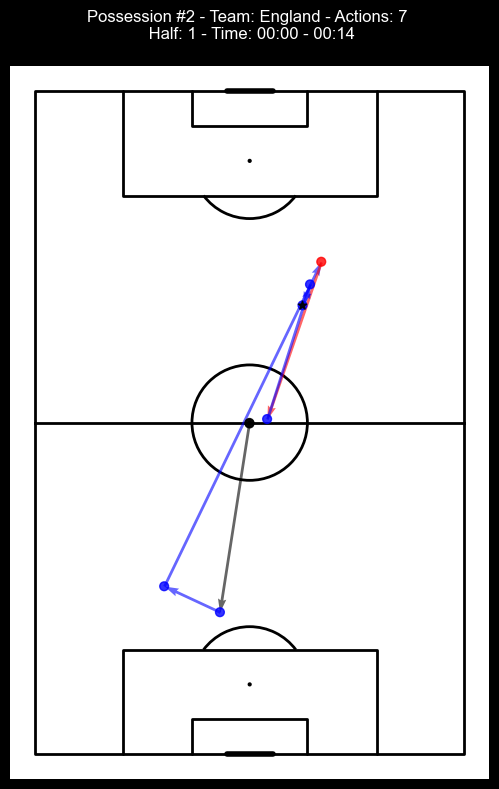

In [41]:
viz = spadl.add_names(possession_feat)
viz["team_name"] = np.where(viz["team_id"] == 941, "Netherlands", "England")
viz["possession"] = pid

fig = plot_possession_actions(viz)
plt.show()


In [ ]:
norm = preprocessor._normalize_features(possession_feat)
print("normalized shape:", norm.shape)

seq = preprocessor._create_simple_sequence(norm)
print("sequence shape:", seq.shape)


In [ ]:
last = possession_feat.tail(SEQUENCE_LENGTH)
label = preprocessor._create_label(last)
print("xG sum:", last["xG"].sum())
print("xT sum:", last["xT"].sum())
print("label:", label)


In [ ]:
match_id = match.get("game_id", match.name)
X, y, p = preprocessor.process_match(match_id, match, events)
print("X:", X.shape, "y:", y.shape, "p:", p.shape)
print("sample y[0], y[8], y[12]:", y[0], y[8], y[12])
